# Ontologias

### Disciplina de Sistemas Inteligentes

### Departamento de Informática e Estatística

### Profa. Nathalia da Cruz Alves


**Nota 1**: Em caso de reprodução, publicação ou compartilhamento deste material, a autoria deverá ser obrigatoriamente mantida.

**Nota 2**: Este material foi elaborado com o auxílio de ferramentas de Inteligência Artificial (IA), utilizadas para o refinamento de explicações e revisão de trechos de código. A autoria e a responsabilidade pelo conteúdo final permanecem com a autora.

Estudante(s): insira seu nome aqui


**Observação**: Solicita-se que sejam informados apenas os nomes dos estudantes efetivamente participantes da atividade.

## Ontologias, Owlready2 e Inferência

Ao final desta atividade, você deverá ser capaz de:

- Criar classes e subclasses em uma ontologia
- Criar indivíduos e relacioná-los por propriedades
- Compreender domínio e alcance (domain e range)
- Utilizar propriedades inversas, assimétricas
- Compreender propriedades simétricas, funcionais e transitivas
- Executar um reasoner para obter conhecimento inferido
- Diferenciar fatos explícitos de fatos inferidos
- Remover indivíduos de uma ontologia;
- Identificar possíveis inconsistências lógicas

### Contextualização
Imagine que uma universidade deseja representar parte de sua estrutura acadêmica por meio de uma ontologia.

Nossa ontologia terá:
- Pessoas
- Alunos
- Professores
- Disciplinas (Programação 1, Programação 2, Programação 3, Estrutura de Dados)
Além disso, teremos relações como:
- professor leciona disciplina;
- aluno está matriculado em disciplina;
- disciplina possui pré-requisito;
- pessoas são amigas;
- professor orienta aluno.


A principal diferença entre uma estrutura de dados comum e uma ontologia é que podemos declarar regras semânticas que permitem ao reasoner descobrir informações que não foram escritas diretamente.





## Preparação do ambiente


In [1]:
%%capture
!pip install owlready2 networkx matplotlib

In [2]:
# Ontologia
from owlready2 import *

# Gráficos
import networkx as nx
import matplotlib.pyplot as plt

## Criando a ontologia


Observação importante sobre a execução das células:
- Nesta atividade, estamos trabalhando com uma ontologia que mantém os indivíduos (instâncias) que são criados durante a execução do código.

- Sempre que uma célula criar uma nova instância, essa instância passa a existir na ontologia. Executar novamente uma célula não significa automaticamente que a instância anterior será apagada. Portanto, é importante observar que o estado da ontologia vai sendo **acumulado** ao longo da execução das células.

**Caso seja necessário começar novamente do zero, é possível destruir a ontologia.**


Como os exercícios são realizados sequencialmente, execute cada célula preferencialmente uma única vez.



Dicas:
- Para destruir a ontologia: onto.destroy()
- Para destruir uma entidade: destroy_entity(entidade)
- Para verificar a lista de todos os indivíduos na ontologia: onto.individuals()

- Para remover relação: instancia.relacao.remove(instancia)
- Antes de repetir uma célula, verifique o estado atual da ontologia utilizando, por exemplo: list(onto.individuals())



In [3]:
onto = get_ontology("http://exemplo.org/onto.owl")

## 1. Definição de classes e disjunção

Criação de classes com a seguinte hierarquia:

Thing

├── Pessoa

│   ├── Aluno

│   └── Professor

│

└── Disciplina






In [4]:
with onto:
    class Pessoa(Thing):
      pass

    class Disciplina(Thing):
      pass

    # Hierarquia (Subclasses)
    class Aluno(Pessoa):
      pass

    class Professor(Pessoa):
      pass

In [5]:
print("Classes da ontologia:")
for cls in onto.classes():
    print("-", cls.name)

Classes da ontologia:
- Pessoa
- Disciplina
- Aluno
- Professor


### Disjunção

Vamos informar ao reasoner que:
- Uma pessoa não pode ser uma disciplina.
- Uma pessoa não pode ser simultaneamente aluno e professor


In [6]:
with onto:
    AllDisjoint([Pessoa, Disciplina])
    AllDisjoint([Aluno, Professor])

### Exercício 1 - AllDisjoint
O que significa declarar: AllDisjoint([Aluno, Professor])? Explique com suas palavras.




## 2. Criando propriedades

Agora vamos definir como os indivíduos podem se relacionar.


"Professor leciona disciplina"

Essa declaração significa:

- Professor ──leciona──> Disciplina

Por exemplo:

- DrJoao ──leciona──> Programação1



In [7]:
with onto:
    class leciona(ObjectProperty):
        domain = [Professor]
        range  = [Disciplina]

### Propriedade inversa

Criamos agora a relação inversa.

Isso estabelece uma relação lógica:
- DrJoao ──leciona──────> Programação1
- DrJoao <──lecionadaPor─ Programação1





In [8]:
with onto:
    class eLecionadaPor(ObjectProperty):
        domain = [Disciplina]
        range = [Professor]
        inverse_property = leciona

Matrículas

Vamos criar as relações entre alunos e disciplinas.

Por exemplo:

- Pedro ──estaMatriculadoEm──> Programação3

é logicamente equivalente à relação inversa:

- Programação3 ──temAlunoMatriculado──> Pedro





In [9]:
with onto:

    class estaMatriculadoEm(ObjectProperty):
        domain = [Aluno]
        range  = [Disciplina]

    class temAlunoMatriculado(ObjectProperty):
        domain = [Disciplina]
        range  = [Aluno]
        inverse_property = estaMatriculadoEm

### Pré-requisitos e transitividade

Agora teremos uma propriedade transitiva.


Considere:

- Programação3 → Programação2
- Programação2 → Programação1

Como a propriedade é transitiva, podemos inferir:

- Programação3 → Programação1

Ou seja:

Programação3 → Programação2 → Programação1



In [10]:
with onto:

    class temComoPreRequisito(ObjectProperty, TransitiveProperty):
        domain = [Disciplina]
        range  = [Disciplina]

### Propriedade simétrica

Agora vamos representar amizade.

Se:
- Pedro é amigo de Ana

a propriedade simétrica permite inferir:

- Ana é amiga de Pedro


Uma relação simétrica funciona nos dois sentidos.
- Pedro ──eAmigoDe──> Ana
- Ana   ──eAmigoDe──> Pedro


In [11]:
with onto:

    class eAmigoDe(ObjectProperty, SymmetricProperty):
        domain = [Pessoa]
        range = [Pessoa]

### Propriedade assimétrica

Vamos representar orientação acadêmica.

Se:
- DrJoao orienta Pedro


não podemos ter simultaneamente:
- Pedro orienta DrJoao

Essa relação é assimétrica.






In [12]:
with onto:

    class orienta(ObjectProperty, AsymmetricProperty):
        domain = [Professor]
        range = [Aluno]

In [13]:
with onto:

    class eOrientadoPor(ObjectProperty):
        domain = [Aluno]
        range = [Professor]
        inverse_property = orienta

## 3. Criando os indivíduos / instâncias

Agora vamos criar as disciplinas:



In [14]:
programacao1 = Disciplina("Programacao1")
programacao2 = Disciplina("Programacao2")
programacao3 = Disciplina("Programacao3")

Professores:


In [15]:
drjoao = Professor("DrJoao")
dramaria = Professor("DrMaria")
drjose = Professor("DrJose")

Alunos:



In [16]:
pedro = Aluno("Pedro")
ana = Aluno("Ana")
mario = Aluno("Mario")

#### Criando os relacionamentos

Professores e disciplinas

In [17]:
drjoao.leciona.append(programacao1)
dramaria.leciona.append(programacao2)
drjose.leciona.append(programacao3)

Matrículas

In [18]:
pedro.estaMatriculadoEm.append(programacao3)
ana.estaMatriculadoEm.append(programacao3)
mario.estaMatriculadoEm.append(programacao1)

Pré-requisitos


In [19]:
programacao2.temComoPreRequisito.append(programacao1)
programacao3.temComoPreRequisito.append(programacao2)

Amizade

In [20]:
pedro.eAmigoDe.append(ana)

Orientação

In [21]:
drjoao.orienta.append(pedro)
dramaria.orienta.append(ana)

#### Visualização

Execute a célula abaixo para visualizar a ontologia criada.



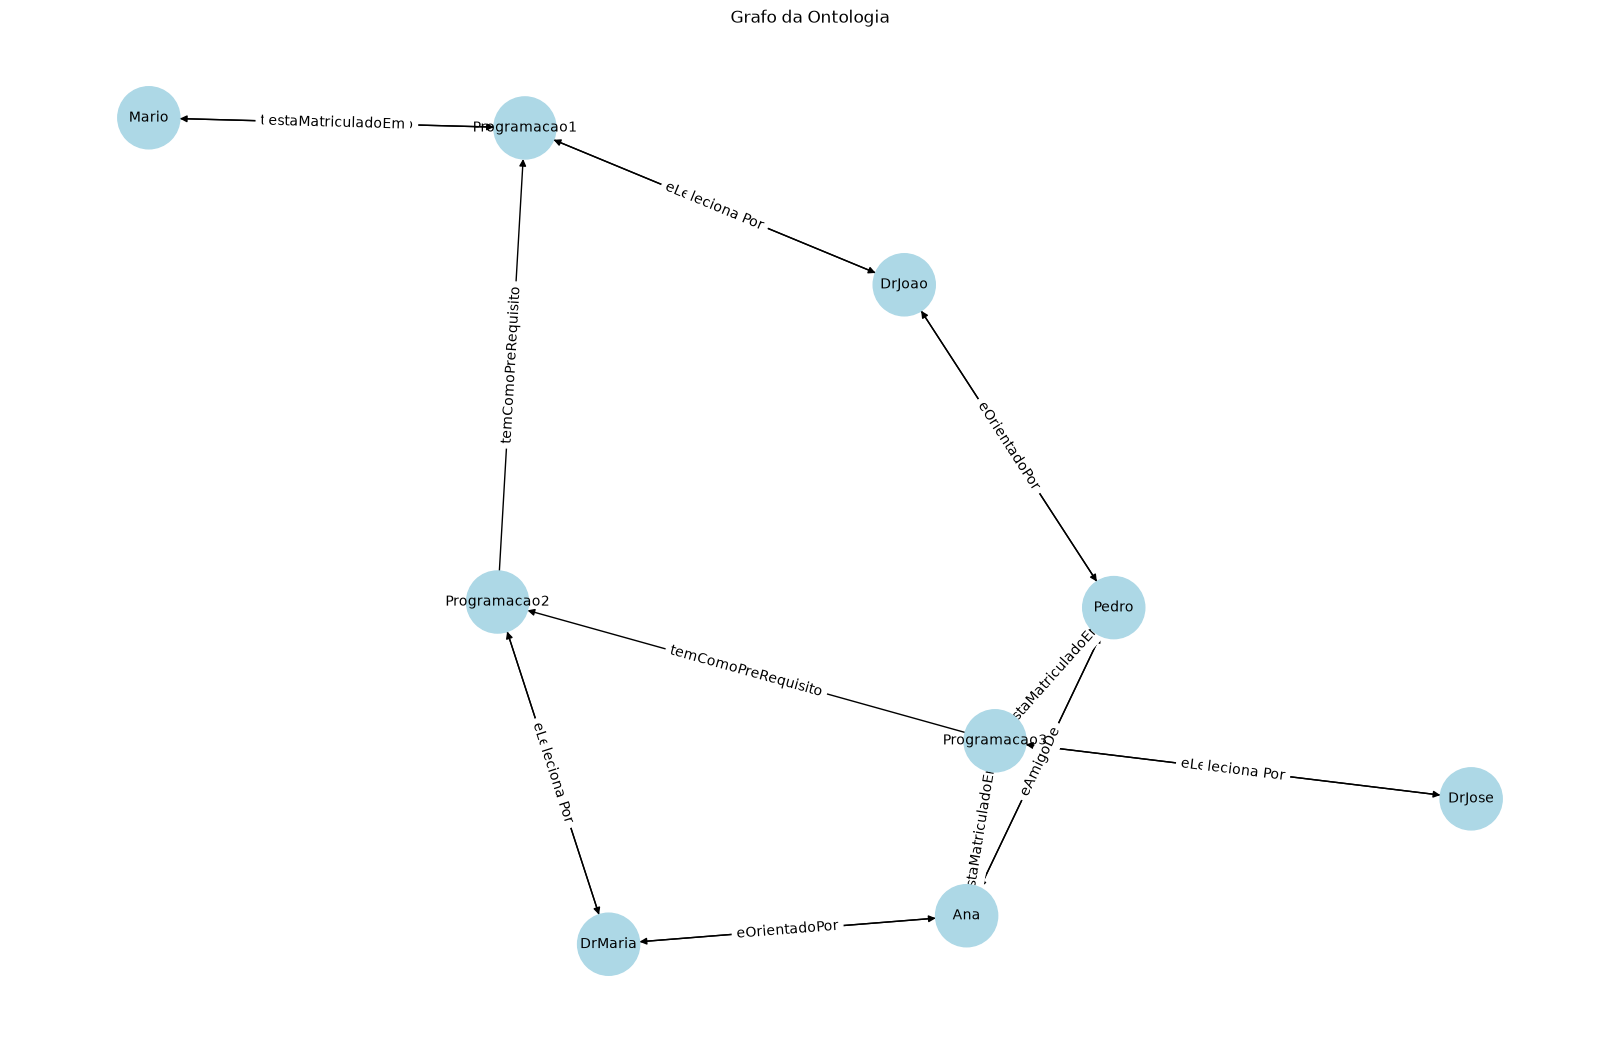

In [22]:
# @title Visualizar a ontologia criada

def visualizar_ontologia(onto):
    G = nx.DiGraph()

    # adicionar nós dos indivíduos
    for ind in onto.individuals():
        G.add_node(ind.name, tipo="individuo")

    # adicionar relações
    for ind in onto.individuals():
        for prop in ind.get_properties():
            for value in prop[ind]:

                # trata ObjectProperty vs DataProperty
                if hasattr(value, "name"):  # indivíduo
                    target = value.name
                    G.add_node(target, tipo="individuo")
                else:  # dado (str, int, etc.)
                    target = str(value)
                    G.add_node(target, tipo="dado")

                G.add_edge(ind.name, target, label=prop.name)

    pos = nx.spring_layout(G)

    plt.figure(figsize=(16, 10)) # Tamanho expandido (16x10 polegadas)

    # cores diferentes
    cores = []
    for node in G.nodes(data=True):
        if node[1].get("tipo") == "dado":
            cores.append("lightgreen")  # dados
        else:
            cores.append("lightblue")   # indivíduos

    nx.draw(G, pos,
            with_labels=True,
            node_color=cores,
            node_size=2000,
            font_size=10)

    edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    plt.title("Grafo da Ontologia")
    plt.show()

visualizar_ontologia(onto)

Cada objeto é como se fosse um mapa.

Se eu pedir o get_properties(), o Python entrega todos os caminhos que saem do nó, não importa se é um amigo, uma disciplina ou um número de matrícula

In [23]:
print(f"Relações da Ana: {list(ana.get_properties())}")

Relações da Ana: [onto.eAmigoDe, onto.estaMatriculadoEm, onto.eOrientadoPor]


Olhando os valores dessas propriedades:

In [24]:
for p in ana.get_properties():
    print(f"{p.name}: {p[ana]}")

eAmigoDe: [onto.Pedro]
estaMatriculadoEm: [onto.Programacao3]
eOrientadoPor: [onto.DrMaria]


Olhando todos os indivíduos e suas relações.

Execute e observe a saída correspondente em texto com a visualização dos nodos acima.


In [25]:
for ind in onto.individuals():
    print(ind.name)
    for prop in ind.get_properties():
        for value in prop[ind]:
            print(f"  {prop.name} → {value}")

Programacao1
  eLecionadaPor → onto.DrJoao
  temAlunoMatriculado → onto.Mario
Programacao2
  eLecionadaPor → onto.DrMaria
  temComoPreRequisito → onto.Programacao1
Programacao3
  eLecionadaPor → onto.DrJose
  temComoPreRequisito → onto.Programacao2
  temAlunoMatriculado → onto.Pedro
  temAlunoMatriculado → onto.Ana
DrJoao
  orienta → onto.Pedro
  leciona → onto.Programacao1
DrMaria
  orienta → onto.Ana
  leciona → onto.Programacao2
DrJose
  leciona → onto.Programacao3
Pedro
  eAmigoDe → onto.Ana
  estaMatriculadoEm → onto.Programacao3
  eOrientadoPor → onto.DrJoao
Ana
  eAmigoDe → onto.Pedro
  estaMatriculadoEm → onto.Programacao3
  eOrientadoPor → onto.DrMaria
Mario
  estaMatriculadoEm → onto.Programacao1


## Conhecimento explícito × conhecimento inferido

Antes de executar o reasoner, observe:



In [26]:
print(f"Quem leciona Programação 1? {programacao1.eLecionadaPor}")
print(f"Quem leciona Programação 2? {programacao2.eLecionadaPor}")
print(f"Quem leciona Programação 3? {programacao3.eLecionadaPor}")

Quem leciona Programação 1? [onto.DrJoao]
Quem leciona Programação 2? [onto.DrMaria]
Quem leciona Programação 3? [onto.DrJose]


In [27]:
print(programacao3.temComoPreRequisito)

[onto.Programacao2]


O resultado contém diretamente:
- Programacao2

Mesmo assim, sabemos que:
- Programação3 → Programação2
- Programação2 → Programação1

Logo, pela transitividade:

- Programação3 → Programação1


Esse é um exemplo de conhecimento **inferido**.



## 4. Executando o Reasoner

Até este ponto, já criamos indivíduos, classes, propriedades e relacionamentos. Algumas características das propriedades, como inversão e simetria, já podem ser percebidas durante a utilização da ontologia, mesmo antes da execução do reasoner.


O reasoner é utilizado para realizar uma análise lógica da ontologia. Ele verifica as regras e restrições declaradas e pode identificar consequências que resultam dessas regras, além de detectar possíveis inconsistências.





In [28]:
try:
    with onto:
        sync_reasoner()

    print("Ontologia consistente!")

except Exception as e:
    print("Inconsistência detectada!")
    print("Tipo:", type(e).__name__)

Inconsistência detectada!
Tipo: FileNotFoundError


* Owlready2 * Running HermiT...
    java -Xmx2000M -cp /opt/conda/lib/python3.13/site-packages/owlready2/hermit:/opt/conda/lib/python3.13/site-packages/owlready2/hermit/HermiT.jar org.semanticweb.HermiT.cli.CommandLine -c -O -D -I file:////tmp/tmp3ks5rypb


### Exercício 2 - Investigando a transitividade

A primeira consulta representa os relacionamentos diretos/assertados.


A consulta INDIRECT_... permite alcançar também relações obtidas indiretamente pela estrutura lógica da ontologia.


Explique por que os dois resultados podem ser diferentes.





In [29]:
print(programacao3.temComoPreRequisito)

print(list(programacao3.INDIRECT_temComoPreRequisito))

[onto.Programacao2]
[onto.Programacao1, onto.Programacao2]


Owlready2 trata propriedades Simétricas e Inversas de um jeito diferente da Transitividade

- Na Simetria: O Reasoner literalmente "escreve" a seta de volta no objeto

In [30]:
print(f"Ana é amiga do Pedro? {pedro in ana.eAmigoDe}")

Ana é amiga do Pedro? True


### Exercício 3 - Aluno novo
Objetivo: Praticar a criação de instâncias e relações diretas.

Crie um novo aluno chamado "Carlos". Matricule Carlos na "Programação 2" e defina que o "Dr. José" é o orientador dele.

Quem aparece como orientador de Carlos (eOrientadoPor)?



In [31]:
Carlos = Aluno("Carlos")
Carlos.estaMatriculadoEm = []
Carlos.estaMatriculadoEm.append(programacao2)
drjose.orienta = []
drjose.orienta.append(Carlos)

print(Carlos.estaMatriculadoEm)
print(drjose.orienta)
print(Carlos.eOrientadoPor)

[onto.Programacao2]
[onto.Carlos]
[onto.DrJose]


### Exercício 4 - Teia de amizades

Objetivo: Entender a propagação da simetria.

Tarefa: Defina que "Carlos" é amigo de "Pedro" e mostre a lista dos amigos do Pedro.


Pergunta: Por que o Carlos aparece na lista do Pedro se você só escreveu a relação em um sentido?




In [32]:
Carlos.eAmigoDe = []
Carlos.eAmigoDe.append(pedro)
print(pedro.eAmigoDe)
print(Carlos.eAmigoDe)

[onto.Ana, onto.Carlos]
[onto.Pedro]


### Exercício 5 - Pré-requisitos

Objetivo: Diferenciar dado real de dado inferido.

Tarefa: Crie uma nova disciplina chamada "Estrutura de Dados". Remova o pré-requisito de "Programação 2" para "Programação 3". Defina que "Programação 3" tem como pré-requisito "Estrutura de Dados" e "Estrutura de Dados" tem como pré-requiquisto "Programação 2".

Pergunta de verificação: Use o comando INDIRECT para descobrir se Programação 1 ainda é um pré-requisito (mesmo que distante) para a Programação 3?



In [39]:
estruturaDeDados = Disciplina("Estrutura de Dados")

if estruturaDeDados not in programacao3.temComoPreRequisito:
    programacao3.temComoPreRequisito.append(estruturaDeDados)

if programacao2 in programacao3.temComoPreRequisito:
    programacao3.temComoPreRequisito.remove(programacao2)

print(programacao3.temComoPreRequisito)

[onto.Estrutura de Dados]


### Exercício 6 - Inconsistência

Objetivo: Compreender como uma ontologia pode identificar situações logicamente inconsistentes a partir das regras e restrições declaradas.

Na ontologia, foi definido anteriormente que:

- Aluno e Professor são classes disjuntas

Isso significa que um mesmo indivíduo não pode pertencer simultaneamente às duas classes.

Agora, crie um indivíduo chamado Marcos como Aluno e, em seguida, declare também que Marcos é um Professor. Execute o reasoner para verificar o que acontece utilizando o código com tratamento de exceção apresentado no tópico 'Executando o Reasoner'







Marcos

 ├── é Aluno

 └── é Professor


Perguntas:

- Por que a situação de Marcos representa uma inconsistência lógica?
- Qual regra da ontologia determina que isso não é permitido?
- O que acontece quando o sync_reasoner() é executado diante dessa inconsistência?
- Qual é a diferença entre simplesmente adicionar Marcos às duas classes e o reasoner identificar que essa combinação é inválida?

In [42]:
#marcos = Aluno("Marcos")
#marcos.is_a.append(Professor)

print(marcos.is_a)

try:
    with onto:
        sync_reasoner()

    print("Ontologia consistente!")

except Exception as e:
    print("Inconsistência detectada!")
    print("Tipo:", type(e).__name__)

[onto.Aluno, onto.Professor]
Inconsistência detectada!
Tipo: FileNotFoundError


* Owlready2 * Running HermiT...
    java -Xmx2000M -cp /opt/conda/lib/python3.13/site-packages/owlready2/hermit:/opt/conda/lib/python3.13/site-packages/owlready2/hermit/HermiT.jar org.semanticweb.HermiT.cli.CommandLine -c -O -D -I file:////tmp/tmp39x5m38t
